In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

torch.manual_seed(42)
print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.12.1


Problem 1 — Masked Mean
Goal: Given x of shape (B, T, C) and a binary mask y of shape (B, T), compute the mean of x along the T dimension only at positions where y == 1. No Python loops allowed.Strategy:

Create a boolean mask from y → shape (B, T)
Expand it to (B, T, 1) so it broadcasts against x's C dimension
Zero out positions where y != 1 using multiplication
Sum along T, divide by the count of valid positions per batch item
The key broadcasting step: mask.unsqueeze(-1) turns (B, T) into (B, T, 1), which automatically broadcasts across C when multiplied with x (B, T, C).Edge case: If a row has zero valid positions, the count is 0 and we'd get NaN. We clamp the denominator to avoid that.

In [3]:
# ── Problem 1: Masked Mean ──────────────────────────────────────────────────

B, T, C = 3, 5, 4
x = torch.randn(B, T, C)
y = torch.randint(0, 2, (B, T))   # random 0/1 mask

print("x shape:", x.shape)
print("y shape:", y.shape)
print("y (mask):\n", y)

# Step 1: Boolean mask (B, T)
mask = (y == 1)

# Step 2: Expand to (B, T, 1) so it broadcasts over C
mask_3d = mask.unsqueeze(-1)          # (B, T, 1)

# Step 3: Zero-out non-masked positions
x_masked = x * mask_3d               # (B, T, C)

# Step 4: Sum over T, divide by count of valid positions per batch item
#   mask.sum(dim=1) → (B,) → unsqueeze to (B, 1) for broadcasting against (B, C)
count = mask.sum(dim=1, keepdim=True).clamp(min=1).float()  # (B, 1)

result = x_masked.sum(dim=1) / count  # (B, C)

print("\nresult shape:", result.shape)   # expect (B, C) = (3, 4)
print("result:\n", result)

# ── Verification: check row 0 manually ─────────────────────────────────────
valid_indices = (y[0] == 1).nonzero(as_tuple=True)[0]
manual_mean_row0 = x[0][valid_indices].mean(dim=0)
print(f"\nManual mean for batch 0 (valid T indices {valid_indices.tolist()}):\n", manual_mean_row0)
print("Matches result[0]:", torch.allclose(result[0], manual_mean_row0))

x shape: torch.Size([3, 5, 4])
y shape: torch.Size([3, 5])
y (mask):
 tensor([[1, 1, 0, 1, 0],
        [1, 0, 1, 0, 0],
        [1, 0, 1, 1, 1]])

result shape: torch.Size([3, 4])
result:
 tensor([[ 0.6258, -0.1022,  0.0296, -0.9826],
        [-0.4949,  0.5600,  0.2746,  1.2702],
        [ 0.2227,  0.7343,  0.2355, -0.1059]])

Manual mean for batch 0 (valid T indices [0, 1, 3]):
 tensor([ 0.6258, -0.1022,  0.0296, -0.9826])
Matches result[0]: True


Problem 2 — Softmax from Scratch
Markdown
Naive softmax for a vector x:
softmax(xi)=exi∑jexj\text{softmax}(x_i) = \frac{e^{x_i}}{\sum_j e^{x_j}}softmax(xi​)=∑j​exj​exi​​
Why it's numerically unstable:

exp(x) grows extremely fast. If any element of x is large (e.g., 1000), exp(1000) overflows to inf in float32 (overflow happens around x ≈ 88.7). Conversely, very negative values underflow to 0, causing a 0/0 NaN in the denominator.
The standard fix — subtract the row maximum:
softmax(xi)=exi−max⁡(x)∑jexj−max⁡(x)\text{softmax}(x_i) = \frac{e^{x_i - \max(x)}}{\sum_j e^{x_j - \max(x)}}softmax(xi​)=∑j​exj​−max(x)exi​−max(x)​
This is mathematically identical (the max cancels in numerator and denominator) but ensures the largest exponent is always e^0 = 1, preventing overflow. The denominator is always ≥ 1, preventing NaN.

In [4]:
# ── Problem 2: Softmax from Scratch ────────────────────────────────────────

def softmax_naive(x, dim=-1):
    """Numerically UNSTABLE — for demonstration only."""
    exp_x = torch.exp(x)
    return exp_x / exp_x.sum(dim=dim, keepdim=True)

def softmax_stable(x, dim=-1):
    """Numerically stable softmax using the max-subtraction trick."""
    x_max = x.max(dim=dim, keepdim=True).values   # (*, 1) — doesn't change result
    exp_x = torch.exp(x - x_max)                  # shift so max value → exp(0)=1
    return exp_x / exp_x.sum(dim=dim, keepdim=True)

# ── Test on normal values ───────────────────────────────────────────────────
x_normal = torch.randn(4, 6)
out_custom = softmax_stable(x_normal, dim=-1)
out_torch  = torch.softmax(x_normal, dim=-1)

print("Max absolute difference (normal input):", (out_custom - out_torch).abs().max().item())
assert torch.allclose(out_custom, out_torch, atol=1e-6), "Mismatch!"
print("✅ Matches torch.softmax to 1e-6")

# ── Demonstrate instability ─────────────────────────────────────────────────
x_large = torch.tensor([1000.0, 1001.0, 1002.0])

print("\n── Large values (x ~ 1000) ──")
print("Naive softmax  :", softmax_naive(x_large))   # all NaN or inf
print("Stable softmax :", softmax_stable(x_large))  # correct
print("torch.softmax  :", torch.softmax(x_large, dim=0))

# ── Verify sums to 1 ───────────────────────────────────────────────────────
print("\nRow sums (should all be 1.0):", out_custom.sum(dim=-1))

Max absolute difference (normal input): 2.9802322387695312e-08
✅ Matches torch.softmax to 1e-6

── Large values (x ~ 1000) ──
Naive softmax  : tensor([nan, nan, nan])
Stable softmax : tensor([0.0900, 0.2447, 0.6652])
torch.softmax  : tensor([0.0900, 0.2447, 0.6652])

Row sums (should all be 1.0): tensor([1.0000, 1.0000, 1.0000, 1.0000])


Problem 3 — Attention Scores Two Ways
Markdown
Given queries Q and keys K of shape (B, T, d), the attention score matrix is:
Scores[b,i,j]=Q[b,i,:]⋅K[b,j,:]\text{Scores}[b, i, j] = Q[b, i, :] \cdot K[b, j, :]Scores[b,i,j]=Q[b,i,:]⋅K[b,j,:]
This is a batched dot product between every query token i and every key token j, producing shape (B, T, T).
Method 1 — torch.einsum:

'bid,bjd->bij' — for each batch b, contract over d, producing a (T, T) score matrix. The index d is summed over (contracted), while i and j are kept free.
Method 2 — @ (matmul) + transpose:

Q @ K.transpose(-1, -2) — transposes the last two dims of K from (B, T, d) to (B, d, T), then batched matmul gives (B, T, d) @ (B, d, T) = (B, T, T).
Both are algebraically identical; einsum is often more readable, while @ is more familiar to those thinking in matrix terms.

In [5]:
# ── Problem 3: Attention Scores Two Ways ───────────────────────────────────

B, T, d = 2, 6, 8
Q = torch.randn(B, T, d)
K = torch.randn(B, T, d)

# Method 1: einsum — explicitly name all dimensions
# 'bid' = Q[batch, query_token, head_dim]
# 'bjd' = K[batch, key_token, head_dim]
# 'd' is contracted (summed); 'b','i','j' are free → output (B, T, T)
scores_einsum = torch.einsum('bid,bjd->bij', Q, K)

# Method 2: batched matmul with transpose
# K.transpose(-1, -2): (B, T, d) → (B, d, T)
# Q @ K^T             : (B, T, d) @ (B, d, T) → (B, T, T)
scores_matmul = Q @ K.transpose(-1, -2)

print("scores_einsum shape:", scores_einsum.shape)   # (2, 6, 6)
print("scores_matmul shape:", scores_matmul.shape)   # (2, 6, 6)

max_diff = (scores_einsum - scores_matmul).abs().max().item()
print(f"\nMax absolute difference: {max_diff:.2e}")
assert torch.allclose(scores_einsum, scores_matmul), "Methods don't match!"
print("✅ Both methods produce exactly equal results")

# ── Also show the scaled version (common in practice) ──────────────────────
scale = d ** 0.5
scores_scaled = scores_matmul / scale
print(f"\nScaled attention scores (÷√d={scale:.2f}), shape: {scores_scaled.shape}")
print("Score matrix [batch 0]:\n", scores_scaled[0].round(decimals=3))

scores_einsum shape: torch.Size([2, 6, 6])
scores_matmul shape: torch.Size([2, 6, 6])

Max absolute difference: 0.00e+00
✅ Both methods produce exactly equal results

Scaled attention scores (÷√d=2.83), shape: torch.Size([2, 6, 6])
Score matrix [batch 0]:
 tensor([[ 1.0220,  0.7830,  0.0130,  0.3200,  1.0100, -0.1740],
        [ 0.7690, -0.9480,  0.6650,  0.5970, -0.4830,  0.4270],
        [ 0.3130, -2.3030,  0.2110,  0.3420, -1.8400,  0.5300],
        [ 0.8220, -1.0440,  1.4570, -0.1740, -0.0430,  0.1160],
        [-1.1210, -0.6130, -0.7810, -0.8670, -0.1750, -0.3770],
        [ 1.9430, -0.8920,  1.2510, -0.3310,  1.0150, -1.2110]])


Problem 4 — Causal Mask
Markdown
In autoregressive models (like GPT), a token at position i should only attend to positions j ≤ i — it cannot "see the future." We enforce this with a causal (lower-triangular) mask.
Construction:

torch.triu(..., diagonal=1) fills the strict upper triangle (j > i) with -inf
On and below the diagonal (j ≤ i): 0 (no change to scores)

Why -inf? When added to raw attention scores and passed through softmax, -inf makes those positions exp(-inf) = 0, completely zeroing out future attention weights.
Result: After softmax, the attention matrix is lower-triangular — each token only distributes weight to past and current tokens.

Causal mask:
 tensor([[0., -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., -inf],
        [0., 0., 0., 0., 0., 0., 0., 0.]])

Attention weights [batch 0] (should be lower-triangular):
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2180, 0.7820, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2950, 0.5510, 0.1540, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.4470, 0.3900, 0.0770, 0.0850, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0310, 0.0780, 0.0460, 0.0620, 0.7830, 0.0000, 0.0000, 0.0000],
        [0.0840, 0.0170, 0.0500, 0.0680, 0.6620, 0.1200, 0.0000, 0.0000],
        [0.3220, 0.0830, 0.1110, 0.0480, 0.1160, 0.0150, 0.3050, 0.0000],
        [0.1560,

/Users/shouryasaxena/Desktop/SOC_MultiModal_Transformer_24b2222/.venv/lib/python3.14/site-packages/matplotlib/colors.py:2551: RuntimeWarning: invalid value encountered in subtract
  resdat -= vmin
/Users/shouryasaxena/Desktop/SOC_MultiModal_Transformer_24b2222/.venv/lib/python3.14/site-packages/matplotlib/colors.py:2552: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)
/Users/shouryasaxena/Desktop/SOC_MultiModal_Transformer_24b2222/.venv/lib/python3.14/site-packages/matplotlib/colors.py:2551: RuntimeWarning: invalid value encountered in subtract
  resdat -= vmin
/Users/shouryasaxena/Desktop/SOC_MultiModal_Transformer_24b2222/.venv/lib/python3.14/site-packages/matplotlib/colors.py:2552: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)


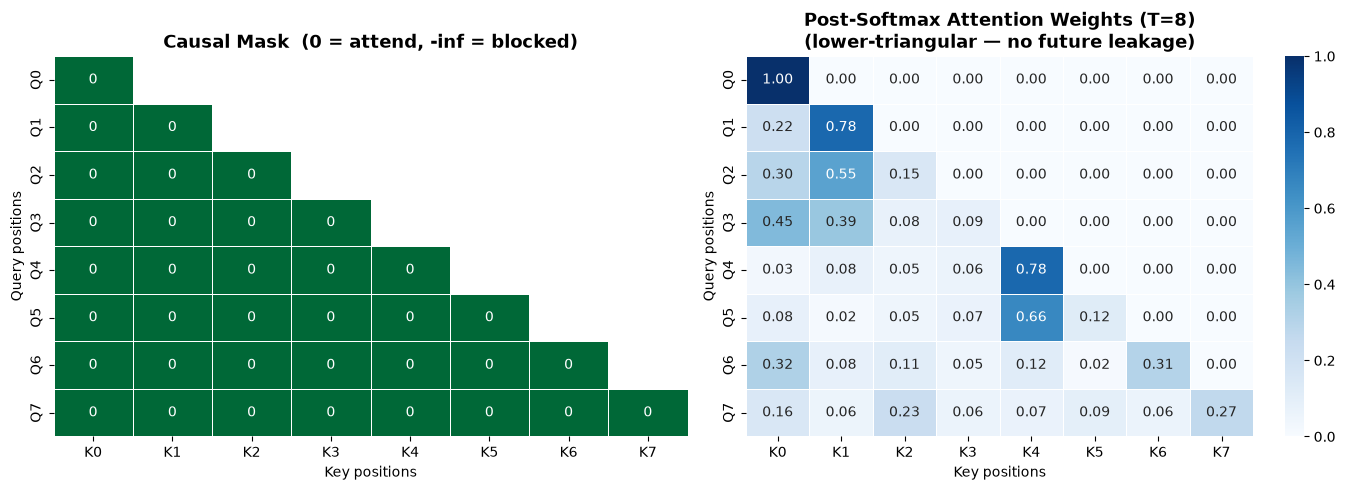

Each row sums to 1.0: tensor([1., 1., 1., 1., 1., 1., 1., 1.])


In [7]:
# ── Problem 4: Causal Mask ─────────────────────────────────────────────────

T = 8

# Build the mask: 0 on/below diagonal, -inf above diagonal
causal_mask = torch.triu(torch.full((T, T), float('-inf')), diagonal=1)

print("Causal mask:\n", causal_mask)


# ── Apply to a random attention score matrix ────────────────────────────────
B = 1
scores_raw = torch.randn(B, T, T)

# Add mask: -inf positions will become 0 after softmax
scores_masked = scores_raw + causal_mask.unsqueeze(0)   # broadcast over B

# Apply softmax along the key dimension (last dim)
attn_weights = torch.softmax(scores_masked, dim=-1)

print("\nAttention weights [batch 0] (should be lower-triangular):")
print(attn_weights[0].round(decimals=3))

# ── Verify: upper triangle is exactly 0 ────────────────────────────────────
upper_triangle = torch.triu(attn_weights[0], diagonal=1)
print(f"\nMax value in upper triangle (should be 0): {upper_triangle.abs().max().item():.2e}")
print("✅ Upper triangle is all zeros — causal masking confirmed")

# ── Visualize as heatmap ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    causal_mask.numpy(),
    ax=axes[0], annot=True, fmt=".0f",
    cmap="RdYlGn_r", linewidths=0.5,
    xticklabels=[f"K{i}" for i in range(T)],
    yticklabels=[f"Q{i}" for i in range(T)],
    cbar=False
)
axes[0].set_title("Causal Mask  (0 = attend, -inf = blocked)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Key positions"); axes[0].set_ylabel("Query positions")

sns.heatmap(
    attn_weights[0].detach().numpy(),
    ax=axes[1], annot=True, fmt=".2f",
    cmap="Blues", linewidths=0.5, vmin=0, vmax=1,
    xticklabels=[f"K{i}" for i in range(T)],
    yticklabels=[f"Q{i}" for i in range(T)]
)
axes[1].set_title("Post-Softmax Attention Weights (T=8)\n(lower-triangular — no future leakage)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Key positions"); axes[1].set_ylabel("Query positions")

plt.tight_layout()
plt.savefig("causal_attention.png", dpi=150, bbox_inches='tight')
plt.show()
print("Each row sums to 1.0:", attn_weights[0].sum(dim=-1).round(decimals=4))

Problem 5 — LayerNorm from Scratch
Markdown
Layer Normalization normalizes each token independently over its feature dimension C. For a single token vector x of size C:
x^=x−μσ2+ϵ,y=γ⊙x^+β\hat{x} = \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}}, \quad y = \gamma \odot \hat{x} + \betax^=σ2+ϵ​x−μ​,y=γ⊙x^+β

μ and σ² are computed per token (over C only) — this is what distinguishes LayerNorm from BatchNorm
ε is a small constant (e.g., 1e-5) for numerical stability (prevents division by zero)
γ (scale) and β (shift) are learnable parameters of shape (C,), initialized to 1 and 0 respectively

Key implementation detail:

Use unbiased=False when computing variance (i.e., divide by N, not N-1), as PyTorch's nn.LayerNorm does the same. Using unbiased=True will cause a mismatch.

In [8]:
# ── Problem 5: LayerNorm from Scratch ──────────────────────────────────────

B, T, C = 2, 5, 8
eps = 1e-5

x = torch.randn(B, T, C)

# Learnable parameters (initialized like PyTorch default: γ=1, β=0)
gamma = torch.ones(C)   # scale
beta  = torch.zeros(C)  # shift

def layernorm_manual(x, gamma, beta, eps=1e-5):
    """
    x     : (B, T, C)
    gamma : (C,)
    beta  : (C,)
    returns: (B, T, C)
    """
    # Mean and variance computed over the LAST dimension (C) only
    # keepdim=True so they broadcast back against x: (B, T, 1)
    mean = x.mean(dim=-1, keepdim=True)                          # (B, T, 1)
    var  = x.var(dim=-1, keepdim=True, unbiased=False)           # (B, T, 1)

    # Normalize
    x_hat = (x - mean) / torch.sqrt(var + eps)                  # (B, T, C)

    # Scale and shift — gamma/beta are (C,) → broadcast to (B, T, C)
    out = gamma * x_hat + beta                                   # (B, T, C)
    return out

out_manual = layernorm_manual(x, gamma, beta, eps)

# ── Compare with nn.LayerNorm ───────────────────────────────────────────────
ln = nn.LayerNorm(normalized_shape=C, eps=eps)
# Copy our gamma/beta into the module (so they're identical)
with torch.no_grad():
    ln.weight.copy_(gamma)
    ln.bias.copy_(beta)

out_torch = ln(x)

max_diff = (out_manual - out_torch).abs().max().item()
print(f"Max absolute difference vs nn.LayerNorm: {max_diff:.2e}")
assert torch.allclose(out_manual, out_torch, atol=1e-5), "Mismatch!"
print("✅ Manual LayerNorm matches nn.LayerNorm to 1e-5")

# ── Inspect normalization properties ───────────────────────────────────────
print(f"\nPer-token mean after norm (should be ≈ 0): {out_manual.mean(dim=-1).abs().max().item():.2e}")
print(f"Per-token std  after norm (should be ≈ 1): {out_manual.std(dim=-1, unbiased=False).mean().item():.6f}")

# ── Show effect on a single token ──────────────────────────────────────────
print(f"\nToken [0, 0] before LayerNorm: {x[0,0].detach().numpy().round(3)}")
print(f"Token [0, 0] after  LayerNorm: {out_manual[0,0].detach().numpy().round(3)}")

Max absolute difference vs nn.LayerNorm: 2.38e-07
✅ Manual LayerNorm matches nn.LayerNorm to 1e-5

Per-token mean after norm (should be ≈ 0): 4.47e-08
Per-token std  after norm (should be ≈ 1): 0.999991

Token [0, 0] before LayerNorm: [ 0.166  1.47  -0.939 -0.601 -0.1   -1.231  0.866 -1.424]
Token [0, 0] after  LayerNorm: [ 0.408  1.77  -0.747 -0.394  0.13  -1.052  1.138 -1.253]


Problem 6 — Manual Gradients
Markdown
Part A: y = (x**2).sum()
By the chain rule:


y=∑ixi2⇒∂y∂xi=2xiy = \sum_i x_i^2 \quad \Rightarrow \quad \frac{\partial y}{\partial x_i} = 2x_iy=i∑​xi2​⇒∂xi​∂y​=2xi​
So x.grad should equal 2 * x.

Part B: y = torch.softmax(x, dim=0).sum()
The key insight: softmax always sums to exactly 1, regardless of the input.
y=∑isoftmax(x)i=1(a constant!)y = \sum_i \text{softmax}(x)_i = 1 \quad \text{(a constant!)}y=i∑​softmax(x)i​=1(a constant!)
The Jacobian of softmax is:


∂si∂xj=si(δij−sj)\frac{\partial s_i}{\partial x_j} = s_i(\delta_{ij} - s_j)∂xj​∂si​​=si​(δij​−sj​)
Summing over all outputs i to get ∂y/∂x_j:


∂y∂xj=∑i∂si∂xj=∑isi(δij−sj)=sj−sj∑isi⏟=1=sj−sj=0\frac{\partial y}{\partial x_j} = \sum_i \frac{\partial s_i}{\partial x_j} = \sum_i s_i(\delta_{ij} - s_j) = s_j - s_j\underbrace{\sum_i s_i}_{=1} = s_j - s_j = 0∂xj​∂y​=i∑​∂xj​∂si​​=i∑​si​(δij​−sj​)=sj​−sj​=1i∑​si​​​=sj​−sj​=0
Every gradient is 0 because the output is a constant — this is confirmed by y.backward().

PART A: y = (x**2).sum()

x            = [ 0.4152 -0.9566 -0.6459  0.9123]
x.grad       = [ 0.8304 -1.9132 -1.2917  1.8246]
2 * x        = [ 0.8304 -1.9132 -1.2917  1.8246]
Match: True
✅ x.grad == 2*x  (derivative of x² is 2x, summed → per-element)

PART B: y = torch.softmax(x, dim=0).sum()

x            = [ 0.8455 -0.0073  0.5794 -0.9202]
softmax(x)   = [0.4231 0.1803 0.3242 0.0724]
softmax sum  = 1.0000000000  ← always exactly 1.0

y = softmax(x).sum() = 1.0000000000  ← constant!

x2.grad      = [0. 0. 0. 0.]
Expected     = [0. 0. 0. 0.]
✅ All gradients are 0.0

EXPLANATION:
  softmax(x) always sums to 1.0 — it's a probability distribution.
  So y = sum(softmax(x)) = 1 for ALL x — a constant function.

  The Jacobian of softmax is:  ∂sᵢ/∂xⱼ = sᵢ(δᵢⱼ - sⱼ)
  Summing over i:
    ∂y/∂xⱼ = Σᵢ sᵢ(δᵢⱼ - sⱼ)
            = sⱼ - sⱼ · Σᵢ sᵢ
            = sⱼ - sⱼ · 1
            = 0

  The gradient is zero everywhere because the output is a constant
  (it equals 1 for every possible input x).



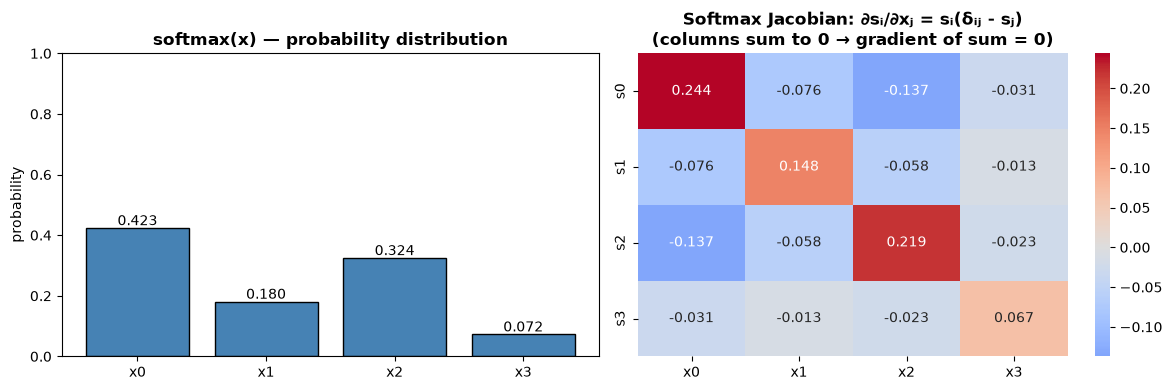

Column sums of Jacobian (each must be 0): [0. 0. 0. 0.]


In [9]:
# ── Problem 6: Manual Gradients ────────────────────────────────────────────

# ── Part A: y = (x**2).sum() ───────────────────────────────────────────────
print("=" * 55)
print("PART A: y = (x**2).sum()")
print("=" * 55)

x = torch.randn(4, requires_grad=True)
print(f"\nx            = {x.detach().numpy().round(4)}")

y = (x ** 2).sum()
y.backward()

autograd_grad = x.grad.clone()
manual_grad   = 2 * x.detach()   # ∂y/∂xᵢ = 2xᵢ

print(f"x.grad       = {autograd_grad.numpy().round(4)}")
print(f"2 * x        = {manual_grad.numpy().round(4)}")
print(f"Match: {torch.allclose(autograd_grad, manual_grad)}")
print("✅ x.grad == 2*x  (derivative of x² is 2x, summed → per-element)")

# ── Part B: y = softmax(x).sum() ────────────────────────────────────────────
print("\n" + "=" * 55)
print("PART B: y = torch.softmax(x, dim=0).sum()")
print("=" * 55)

x2 = torch.randn(4, requires_grad=True)
print(f"\nx            = {x2.detach().numpy().round(4)}")

s = torch.softmax(x2, dim=0)
print(f"softmax(x)   = {s.detach().numpy().round(4)}")
print(f"softmax sum  = {s.sum().item():.10f}  ← always exactly 1.0")

y2 = s.sum()
print(f"\ny = softmax(x).sum() = {y2.item():.10f}  ← constant!")
y2.backward()

print(f"\nx2.grad      = {x2.grad.numpy().round(6)}")
print("Expected     = [0. 0. 0. 0.]")

assert torch.allclose(x2.grad, torch.zeros(4), atol=1e-6)
print("✅ All gradients are 0.0")

# ── Intuitive explanation via Jacobian ──────────────────────────────────────
print("""
EXPLANATION:
  softmax(x) always sums to 1.0 — it's a probability distribution.
  So y = sum(softmax(x)) = 1 for ALL x — a constant function.

  The Jacobian of softmax is:  ∂sᵢ/∂xⱼ = sᵢ(δᵢⱼ - sⱼ)
  Summing over i:
    ∂y/∂xⱼ = Σᵢ sᵢ(δᵢⱼ - sⱼ)
            = sⱼ - sⱼ · Σᵢ sᵢ
            = sⱼ - sⱼ · 1
            = 0

  The gradient is zero everywhere because the output is a constant
  (it equals 1 for every possible input x).
""")

# ── Visualize the softmax Jacobian matrix ───────────────────────────────────
s_vals = s.detach()
jacobian = torch.diag(s_vals) - torch.outer(s_vals, s_vals)  # sᵢ(δᵢⱼ - sⱼ)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(4), s_vals.numpy(), color='steelblue', edgecolor='k')
axes[0].set_title("softmax(x) — probability distribution", fontweight='bold')
axes[0].set_xticks(range(4)); axes[0].set_xticklabels([f'x{i}' for i in range(4)])
axes[0].set_ylabel("probability"); axes[0].set_ylim(0, 1)
for i, v in enumerate(s_vals): axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)

sns.heatmap(
    jacobian.numpy(), ax=axes[1],
    annot=True, fmt=".3f", cmap="coolwarm", center=0,
    xticklabels=[f'x{i}' for i in range(4)],
    yticklabels=[f's{i}' for i in range(4)]
)
axes[1].set_title("Softmax Jacobian: ∂sᵢ/∂xⱼ = sᵢ(δᵢⱼ - sⱼ)\n(columns sum to 0 → gradient of sum = 0)", fontweight='bold')

plt.tight_layout()
plt.savefig("softmax_jacobian.png", dpi=150, bbox_inches='tight')
plt.show()

print("Column sums of Jacobian (each must be 0):", jacobian.sum(dim=0).numpy().round(6))